# Agentic Clinic Analyst

This notebook builds an agent that does the first pass of data analysis for a clinic
that doesn't have anybody on staff to do it. You give it a CSV of clinic data and one
sentence about what you want to know. It reads the file to see what columns and how
many rows it has to work with, then decides on its own which analyses are worth
running. For each one it prints out what it's thinking, runs the pandas and matplotlib
code, and looks at the result before deciding what to do next. When it's finished it
writes a short paragraph on each chart explaining what that chart shows and why it
matters to the clinic.

Gemini does the reasoning and the writing. Pandas and matplotlib do the actual data
work. The agent picks its own charts and decides how many to make, anywhere from two
to four.

## System Design

Before the agent loop starts, the dataset gets profiled once: a function reads the CSV
and turns the columns, types, and value counts into text. This isn't something the
agent calls, it's the starting information the agent is given to reason over, the same
way a person would be handed a spec sheet before being asked to make decisions from it.

The agent itself has two tools it can call. A charting function that takes a chart
type and columns, draws a bar, line, or scatter chart, and returns the numbers as
text. And a writing function that turns those numbers into a plain-language paragraph.

The loop that ties them together is a ReAct pattern: Thought, Action, Observation,
repeated. Gemini is given the data profile and the clinic's stated goal, and on each
pass it explains its reasoning, picks one analysis, and that analysis runs. The result
comes back as an Observation, which gets added to a running history before the next
pass, so each decision is made with knowledge of everything already tried. Gemini
decides when it's done, capped between two and four analyses so the output stays a
manageable size.

Two safeguards are built into this loop. Gemini can only request a bar, line, or
scatter chart, nothing else is allowed to run. And if the clinic's stated goal has
nothing to do with the dataset, the agent is instructed to say so and fall back to
general analyses instead of forcing an answer that isn't there.

This integrates four capstones. AI Programming Foundations covers the Python
implementation: the loop, the functions, and the file handling. Conduct a Statistical
Analysis Using Python covers the cleaning, the data profiling, and the charting.
Design of Autonomous and Semi-Autonomous Agentic Workflows covers the ReAct loop
itself, the agent deciding its own actions and reasoning over its own results.
Generative AI Applications covers Gemini's role as the reasoning and writing engine
that powers every decision the agent makes and every paragraph it writes.

## Imports

Loading everything the notebook needs before anything else runs.

"os" and "load_dotenv" are for pulling the Gemini API key out of the .env file
instead of typing it into the notebook, where it would end up on GitHub.

"pandas" reads the CSV and does all the actual data work, things like counting
rows, grouping columns and averaging numbers.

"matplotlib.pyplot" draws the charts and saves them out as PNG files.

"json" is here because the agent sends its decisions back as JSON. When it picks
an analysis it replies with the chart type and which columns to use, and json
turns that reply into something Python can work with.

"genai" is the Gemini connection. Gemini is what decides which
analyses to run and writes the paragraph on each chart at the end.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from google import genai
from dotenv import load_dotenv

## API Key and Client

Setting up the connection to Gemini.

The key gets pulled out of the .env file instead of being typed into the notebook.
"load_dotenv()" reads that file and "os.getenv" grabs the value out of it. Since .env
is listed in .gitignore, the key never gets uploaded to GitHub with the rest of the
project.

There's a check here that prints whether the key was found. It prints a confirmation
rather than the key itself, so the notebook shows the step actually ran without
putting the key in the output.

"genai.Client" is the connection object. Everything the agent asks Gemini goes through
this. The model name isn't set here, it gets passed in on each individual call later on.

In [2]:
load_dotenv()

gemini_key = os.getenv("GEMINI_API_KEY")

if gemini_key is None:
    print("No key found. Check the .env file.")
else:
    print("Key loaded.")

engine = genai.Client(api_key=gemini_key)

Key loaded.


## Model Test

Before building anything on top of Gemini, this cell confirms the connection actually
works. The Environment Setup asks for a minimal test that runs a representative
component, and this is it. If the key is wrong or the model name is bad, it fails here
instead of failing somewhere in the middle of the agent loop where it's harder to
figure out what broke.

The model name is stored in "chosen_model" rather than typed into every call. It gets
passed to Gemini several times later on, so keeping it in one place means changing
models is a one line edit.

"generate_content" is how every request to Gemini gets made. "model" is which model to
use and "contents" is the prompt. The reply comes back as an object, and ".text" pulls
the actual words out of it. The prompt here asks for one word so it's obvious at a
glance whether it worked.

The model is Gemini 3.5 Flash. The agent has to return structured output on every step
of the loop and the loop breaks if that output comes back malformed, so the stronger
model was worth it for the reliability rather than for the writing quality.

In [3]:
chosen_model = "gemini-3.5-flash"

test_reply = engine.models.generate_content(
    model=chosen_model,
    contents="Reply with the word working and nothing else."
)

print(test_reply.text)

working


## Loading the Data

Reading the clinic data in and taking a first look at it.

The file is a set of hospital admission records from Kaggle. It has patient
demographics, what they were admitted for, which insurance provider covered it, what
they were billed, and the dates they came in and left.

"pd.read_csv" pulls the file into a dataframe, which is the table format pandas works
in. The file sits in the same folder as the notebook, so the filename on its own is
enough of a path.

"shape" gives back the number of rows and columns. The agent needs the row count later
to know how much data it's dealing with, so this is where that comes from.

"head" prints the first five rows. This is here so the columns and what kind of values
are in them can actually be seen rather than assumed.

In [4]:
csv_file = "healthcare_dataset.csv"

clinic_records = pd.read_csv(csv_file)

print("Rows:", clinic_records.shape[0])
print("Columns:", clinic_records.shape[1])

clinic_records.head()

Rows: 55500
Columns: 15


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Checking the Data

Looking at the condition of the data before doing anything with it.

This runs as its own step instead of being skipped over, because what comes back is
what decides the cleaning. Guessing at what needs fixing and guessing right aren't
the same thing.

"isnull().sum()" counts empty values in each column. Blanks throw off an average or
leave gaps in a chart.

"duplicated().sum()" counts rows that are exact copies of another row. Duplicates get
counted twice in any total.

In [5]:
print("Missing values per column:")
print(clinic_records.isnull().sum())

print()
print("Duplicate rows:", clinic_records.duplicated().sum())

Missing values per column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate rows: 534


## Column Types

"dtypes" shows the type pandas assigned to each column. This one matters most for the
two date columns, because dates read in from a CSV come through as plain text, and text
can't be sorted by time or grouped by month.

In [6]:
print("Data type of each column:")
print(clinic_records.dtypes)

Data type of each column:
Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object


## Unique Values Per Column

"nunique()" counts how many different values are in each column. This is what separates
the columns that can be charted from the ones that can't. Three or four values makes a
readable bar chart. Thousands of values makes a mess.

In [7]:
print("Unique values per column:")
print(clinic_records.nunique())

Unique values per column:
Name                  49992
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Room Number             400
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
dtype: int64


## Cleaning the Data

Fixing the three problems the checks turned up.

"drop_duplicates()" removes the 534 exact copies found earlier. Those rows would get
counted twice in any total or average.

"pd.to_datetime" converts the two date columns from text into real dates. They came in
as "str", which means pandas was treating them as words. Sorted as text, 2019-08-20
lands next to 2019-08-26 by luck of the characters rather than because one comes before
the other, and nothing can be grouped by month or year. Converting them is what makes a
chart over time possible at all.

"round(2)" cuts Billing Amount down to two decimal places. It came in with six, which
is meaningless for money and clutters up anything it gets printed on.

The columns that turned out to be noise are left in on purpose. Deciding that Doctor
and Hospital aren't worth charting is the agent's call to make, not something to decide
for it here. This cell only handles the mechanical fixes, the ones with no judgment
involved.

In [8]:
clinic_records = clinic_records.drop_duplicates()

clinic_records["Date of Admission"] = pd.to_datetime(clinic_records["Date of Admission"])
clinic_records["Discharge Date"] = pd.to_datetime(clinic_records["Discharge Date"])

clinic_records["Billing Amount"] = clinic_records["Billing Amount"].round(2)

print("Rows after cleaning:", clinic_records.shape[0])
print("Date of Admission type:", clinic_records["Date of Admission"].dtype)
print("Discharge Date type:", clinic_records["Discharge Date"].dtype)

Rows after cleaning: 54966
Date of Admission type: datetime64[us]
Discharge Date type: datetime64[us]


## The Data Summary Tool

This builds the description of the data that gets handed to the agent.

The agent can't see the CSV. It only sees what gets handed to it as text, so this
function turns the dataframe into a written description it can read. Row count, then
every column with its type and how many different values are in it. For columns with
ten or fewer values it lists the actual values too, since knowing a column holds
Emergency, Elective and Urgent is more useful than knowing it holds three of something.

Nothing here is specific to this file. It loops over whatever columns exist, so
dropping in a different CSV produces a different summary with no code changes.

This is where the information the agent reasons over comes from, including what it needs to rule columns out. 
The unique counts are in the summary, so it can work out for itself that a column
with 40,000 different values isn't worth charting. That decision is left to the agent
rather than being made here.

In [9]:
def build_data_summary(table):
    notes = "The dataset has " + str(table.shape[0]) + " rows.\n"
    notes = notes + "Columns:\n"

    for column_name in table.columns:
        how_many = table[column_name].nunique()
        notes = notes + column_name
        notes = notes + " | type: " + str(table[column_name].dtype)
        notes = notes + " | unique values: " + str(how_many)

        if how_many <= 10:
            notes = notes + " | values: " + str(list(table[column_name].unique()))

        notes = notes + "\n"

    return notes


data_summary = build_data_summary(clinic_records)
print(data_summary)

The dataset has 54966 rows.
Columns:
Name | type: str | unique values: 49992
Age | type: int64 | unique values: 77
Gender | type: str | unique values: 2 | values: ['Male', 'Female']
Blood Type | type: str | unique values: 8 | values: ['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']
Medical Condition | type: str | unique values: 6 | values: ['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
Date of Admission | type: datetime64[us] | unique values: 1827
Doctor | type: str | unique values: 40341
Hospital | type: str | unique values: 39876
Insurance Provider | type: str | unique values: 5 | values: ['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna']
Billing Amount | type: float64 | unique values: 49760
Room Number | type: int64 | unique values: 400
Admission Type | type: str | unique values: 3 | values: ['Urgent', 'Emergency', 'Elective']
Discharge Date | type: datetime64[us] | unique values: 1856
Medication | type: str | unique values: 5 | values: ['Pa

## The Chart Tool

This is the tool the agent actually calls.

It takes a chart type, the columns to use, and a title, then draws the chart and hands
back a text readout of what was in it. The readout matters as much as the chart does,
because the agent can't see images. Reading the numbers back is how it knows what
happened before it decides what to do next.

"allowed_charts" is the limit on what the agent can do. Bar, line and scatter, and
anything else gets refused. Three types the results of which can be read and explained
without guessing, rather than the agent reaching for something that produces a chart
nobody can interpret.

Each type gets handled differently. Bar either counts how many records fall in each
category or averages a number across them. Line groups the records by month so there's
something ordered to plot across, since plotting 1,827 individual days would be
unreadable. Scatter puts two numbers against each other and also calculates the
correlation between them, which is the single most useful number for judging whether
what the chart shows means anything.

Every chart gets saved into the charts folder as a PNG as well as displayed here.

Colors are steelblue to match the charts from the Conduct a Statistical Analysis
capstone.

In [10]:
os.makedirs("charts", exist_ok=True)

allowed_charts = ["bar", "line", "scatter"]


def draw_chart(chart_kind, x_column, y_column, chart_title):
    if chart_kind not in allowed_charts:
        return "That chart type is not allowed. Pick bar, line or scatter."

    plt.figure(figsize=(9, 5))

    if chart_kind == "bar":
        if y_column == "count":
            plotted = clinic_records[x_column].value_counts()
            plt.ylabel("Number of records")
        else:
            plotted = clinic_records.groupby(x_column)[y_column].mean()
            plt.ylabel("Average " + y_column)
        plotted.plot(kind="bar", color="steelblue")
        plt.xlabel(x_column)
        readout = plotted.round(2).to_string()

    elif chart_kind == "line":
        by_month = clinic_records.groupby(clinic_records[x_column].dt.to_period("M"))
        if y_column == "count":
            plotted = by_month.size()
            plt.ylabel("Number of records")
        else:
            plotted = by_month[y_column].mean()
            plt.ylabel("Average " + y_column)
        plotted.index = plotted.index.astype(str)
        plotted.plot(kind="line", color="steelblue")
        plt.xlabel("Month")
        readout = plotted.round(2).to_string()

    elif chart_kind == "scatter":
        plt.scatter(clinic_records[x_column], clinic_records[y_column],
                    color="steelblue", s=4)
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        together = clinic_records[x_column].corr(clinic_records[y_column])
        readout = "Correlation between " + x_column + " and " + y_column
        readout = readout + ": " + str(round(together, 3))

    plt.title(chart_title)
    plt.tight_layout()

    file_name = "charts/" + chart_title.replace(" ", "_") + ".png"
    plt.savefig(file_name)
    plt.show()

    return readout

## Asking Gemini What To Do Next

This is where the agent actually reasons. It gets handed the data summary, the goal the
user typed in, and a log of what's already been charted, and it has to reply with
exactly one of two things: another analysis to run, or a decision that it's done.

The prompt lays out the rules directly rather than hoping the model figures them out.
Chart type has to be bar, line or scatter. Columns have to be real column names from the
summary, not invented ones. And it has to explain its Thought before naming the Action,
same as it did in the report writer.

The reply has to come back as JSON so the code can read it automatically. That's the
part that broke most often on the last project, so the prompt spells out the exact
shape expected and nothing else. Gemini 3.5 was picked partly for this, since sticking
to a strict format is exactly where a stronger model helps most.

The agent decides for itself when it's done. The prompt asks it to stop once it has run
four analyses, and the loop also stops on its own at four whether the agent agrees or
not. Asking is not the same as enforcing, so both are in place.

In [11]:
def ask_gemini_for_next_step(summary_text, user_goal, history_text, chart_count):

    instructions = "You are a data analysis agent helping a clinic understand their data.\n"
    instructions = instructions + "Here is what the dataset looks like:\n" + summary_text + "\n"
    instructions = instructions + "The clinic's goal is: " + user_goal + "\n"
    instructions = instructions + "Analyses done so far:\n" + history_text + "\n"

    if chart_count < 2:
        instructions = instructions + "You must pick another analysis. Do not stop yet.\n"
    elif chart_count >= 4:
        instructions = instructions + "You have done enough analyses. You must stop now.\n"
    else:
        instructions = instructions + "You may pick another analysis or stop if you feel the goal is met.\n"

    instructions = instructions + "If the clinic's goal has nothing to do with the dataset above, explain that in your thought, choose reasonable general analyses instead, and proceed.\n"
    
    instructions = instructions + "\nRules:\n"
    instructions = instructions + "- chart_type must be bar, line or scatter\n"
    instructions = instructions + "- x_column and y_column must be real column names from the dataset above\n"
    instructions = instructions + "- for bar or line charts, y_column can be the word count instead of a column name\n"
    instructions = instructions + "- explain your thought before your action\n"
    instructions = instructions + "\nReply with ONLY JSON, no other text, in one of these two shapes:\n"
    instructions = instructions + '{"stop": false, "thought": "...", "chart_type": "...", "x_column": "...", "y_column": "...", "title": "..."}\n'
    instructions = instructions + 'or\n'
    instructions = instructions + '{"stop": true, "thought": "..."}\n'

    reply = engine.models.generate_content(
        model=chosen_model,
        contents=instructions
    )

    reply_text = reply.text.strip()

    if reply_text.startswith("```"):
        reply_text = reply_text.strip("`")
        reply_text = reply_text.replace("json", "", 1)
        reply_text = reply_text.strip()

    decision = json.loads(reply_text)
    return decision

## The Agent Loop

This is the ReAct loop. Same pattern as the report writer, Thought, Action, Observation,
repeated until the agent decides it's done.

Each pass asks Gemini for the next step. If it says stop, the loop ends. Otherwise it
prints the Thought, runs the chart through "draw_chart" as the Action, and the text that
comes back is the Observation. That observation gets added to the history log before the
next pass, so each decision is made with knowledge of everything already tried, not just
the original data summary.

Everything gets saved into a list as it goes; chart type, columns, title, thought, and
the observation text. That list is what the paragraph-writing step and the notebook's
own record of the run both pull from afterward.

If "draw_chart" refuses a chart because the type isn't allowed, that refusal gets logged
as the observation too, and the loop keeps going instead of crashing. The agent sees
that its request failed and has to try something else next time.

In [12]:
def run_agent(user_goal):
    history_log = "None yet."
    results = []
    chart_count = 0

    while True:
        decision = ask_gemini_for_next_step(data_summary, user_goal, history_log, chart_count)

        if decision["stop"] == True:
            print("Thought:", decision["thought"])
            print("Agent has decided to stop.")
            break

        print("Thought:", decision["thought"])
        print("Action:", decision["chart_type"], decision["x_column"], decision["y_column"])

        observation = draw_chart(
            decision["chart_type"],
            decision["x_column"],
            decision["y_column"],
            decision["title"]
        )

        print("Observation:", observation)
        print()

        results.append({
            "chart_type": decision["chart_type"],
            "x_column": decision["x_column"],
            "y_column": decision["y_column"],
            "title": decision["title"],
            "thought": decision["thought"],
            "observation": observation
        })

        history_log = history_log + "\n" + decision["title"] + " -> " + observation
        chart_count = chart_count + 1
        
        if chart_count >= 4:
            print("Reached the maximum of four analyses. Stopping.")
            break

    return results

## The Clinic's Goal

For this run, the clinic's goal is set directly in the notebook.

In [13]:
user_goal = "I want to understand what's driving our costs and admissions."

Thought: To help the clinic understand what is driving their costs, I will analyze the relationship between 'Medical Condition' and 'Billing Amount'. By plotting a bar chart of Billing Amount across different Medical Conditions, we can see if certain health conditions are associated with higher charges.
Action: bar Medical Condition Billing Amount


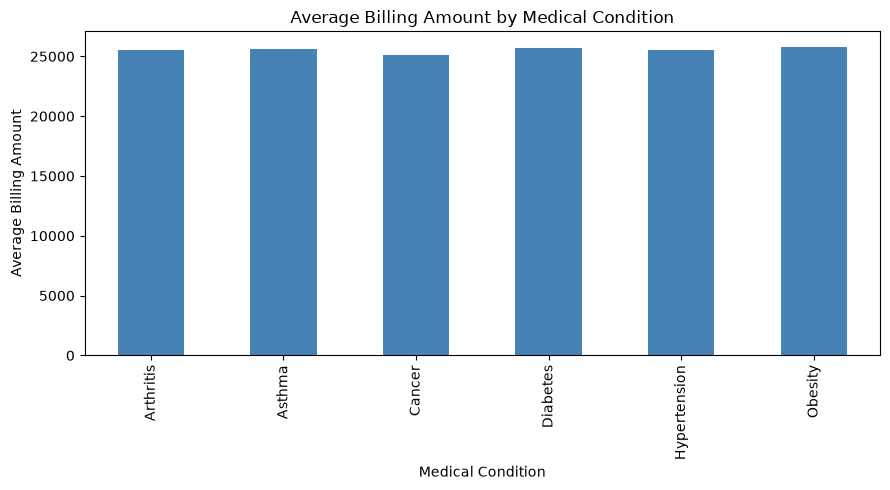

Observation: Medical Condition
Arthritis       25511.78
Asthma          25633.46
Cancer          25152.32
Diabetes        25660.48
Hypertension    25503.06
Obesity         25804.36

Thought: To help the clinic understand what is driving their admissions, we should look at the distribution of admissions across different admission types (Urgent, Emergency, Elective). This will show which category contributes the most to their admission volume.
Action: bar Admission Type count


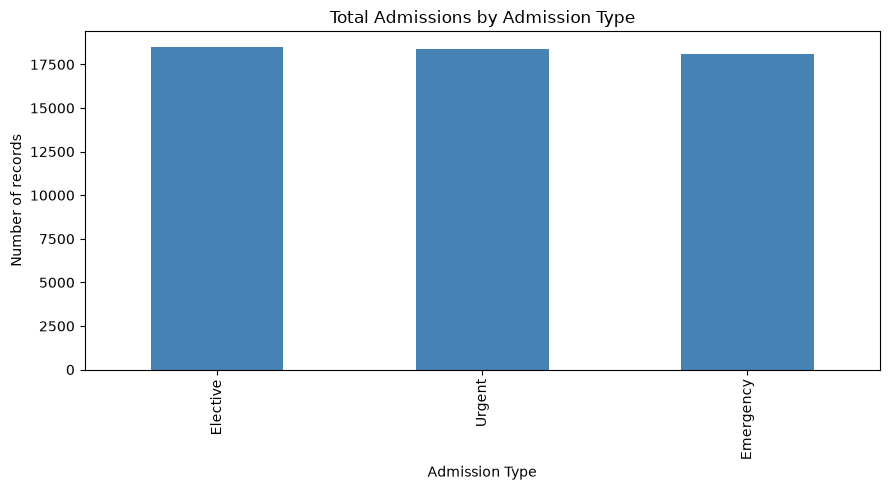

Observation: Admission Type
Elective     18473
Urgent       18391
Emergency    18102

Thought: To help the clinic understand what is driving their admissions, I will analyze the total number of admissions for each medical condition. This will show which diseases or conditions are responsible for the most hospital visits.
Action: bar Medical Condition count


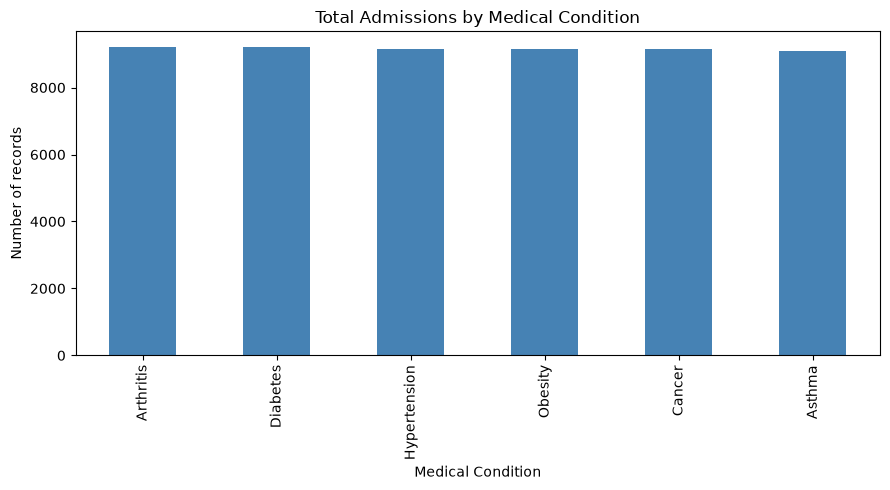

Observation: Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095

Thought: To better understand what is driving costs, I will analyze the relationship between Insurance Providers and Billing Amount. This will help determine if certain insurance providers are associated with higher billing amounts on average.
Action: bar Insurance Provider Billing Amount


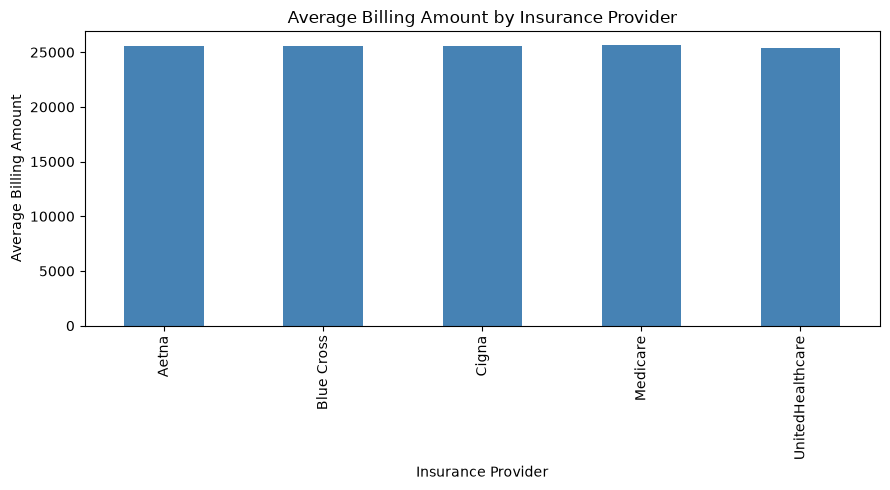

Observation: Insurance Provider
Aetna               25549.69
Blue Cross          25603.46
Cigna               25526.00
Medicare            25628.32
UnitedHealthcare    25414.51

Reached the maximum of four analyses. Stopping.


In [14]:
agent_results = run_agent(user_goal)

## Writing Up Each Chart

The last step. For every chart the agent ran, this asks Gemini to write a short
paragraph explaining what it shows and why it matters to a clinic, using the actual
numbers from that chart's observation rather than guessing.

Each paragraph is written on its own, one chart at a time, so the writing for one chart
can't get mixed up with the numbers from another.

In [15]:
def write_chart_explanation(item):
    instructions = "You are explaining a chart to someone who runs a clinic and has no data background.\n"
    instructions = instructions + "Chart title: " + item["title"] + "\n"
    instructions = instructions + "Chart type: " + item["chart_type"] + "\n"
    instructions = instructions + "What was compared: " + item["x_column"] + " vs " + item["y_column"] + "\n"
    instructions = instructions + "The actual numbers from the chart: " + item["observation"] + "\n"
    instructions = instructions + "Write one short paragraph, plain language, no jargon, explaining what this chart shows and why it matters to the clinic. If the numbers are close to the same across the board, say that plainly instead of inventing a difference.\n"

    reply = engine.models.generate_content(
        model=chosen_model,
        contents=instructions
    )

    return reply.text.strip()


for item in agent_results:
    print(item["title"])
    print(write_chart_explanation(item))
    print()

Average Billing Amount by Medical Condition
This chart compares the average bill for patients with different chronic health issues, such as arthritis, diabetes, and asthma. What stands out immediately is that the average billing amount is almost exactly the same across the board, hovering right around $25,000 to $25,800 regardless of the diagnosis. For your clinic, this means your revenue is remarkably consistent and predictable. You can plan your budget and resources knowing that treating different conditions brings in virtually the same average billing, making financial forecasting much simpler for your business.

Total Admissions by Admission Type
This chart shows how your clinic's patient admissions are divided among planned visits (Elective), patients needing quick care (Urgent), and immediate crises (Emergency). Remarkably, your patient volume is almost perfectly split across all three categories, with each group bringing in roughly 18,000 admissions. This matters to your busines

## Overall Summary

The paragraphs above cover each chart on its own, but the clinic asked one
question at the start, and this ties everything back to it directly. It's the same
prompt pattern as the per-chart write-up, just handed all observations at once
instead of one, so it can speak to the pattern across all of them rather than repeating
itself.

In [16]:
def write_overall_summary(goal, all_results):
    instructions = "You are summarizing a full data analysis session for a clinic that has no data background.\n"
    instructions = instructions + "The clinic's original question was: " + goal + "\n"
    instructions = instructions + "Here is what was found in each analysis:\n"

    for item in all_results:
        instructions = instructions + "- " + item["title"] + ": " + item["observation"] + "\n"

    instructions = instructions + "Write one short paragraph directly answering the clinic's original question based on these findings. "
    instructions = instructions + "If the findings show that nothing stands out or nothing varies much, say that plainly rather than forcing an answer that isn't there.\n"

    reply = engine.models.generate_content(
        model=chosen_model,
        contents=instructions
    )

    return reply.text.strip()


overall_summary = write_overall_summary(user_goal, agent_results)
print(overall_summary)

Based on our analysis, there is actually no single condition, insurance provider, or visit type that is disproportionately driving your clinic's costs or patient volume. Instead, your data is remarkably uniform across the board: your average bills stay almost identical (hovering around $25,000 to $25,800) regardless of the medical condition treated or the insurance company billing it, and your total admissions are nearly perfectly split across all types of visits (elective, urgent, and emergency) and diagnoses. In short, nothing stands out as a primary driver because your costs and admissions are evenly distributed and highly consistent across all areas of your clinic.
